### 更新数据

In [1]:
import akshare as ak

df = ak.stock_hk_index_daily_sina(symbol="HSI")
df.to_csv("data/hsi.csv", index=False, encoding="utf-8-sig")

### RSI 分位图

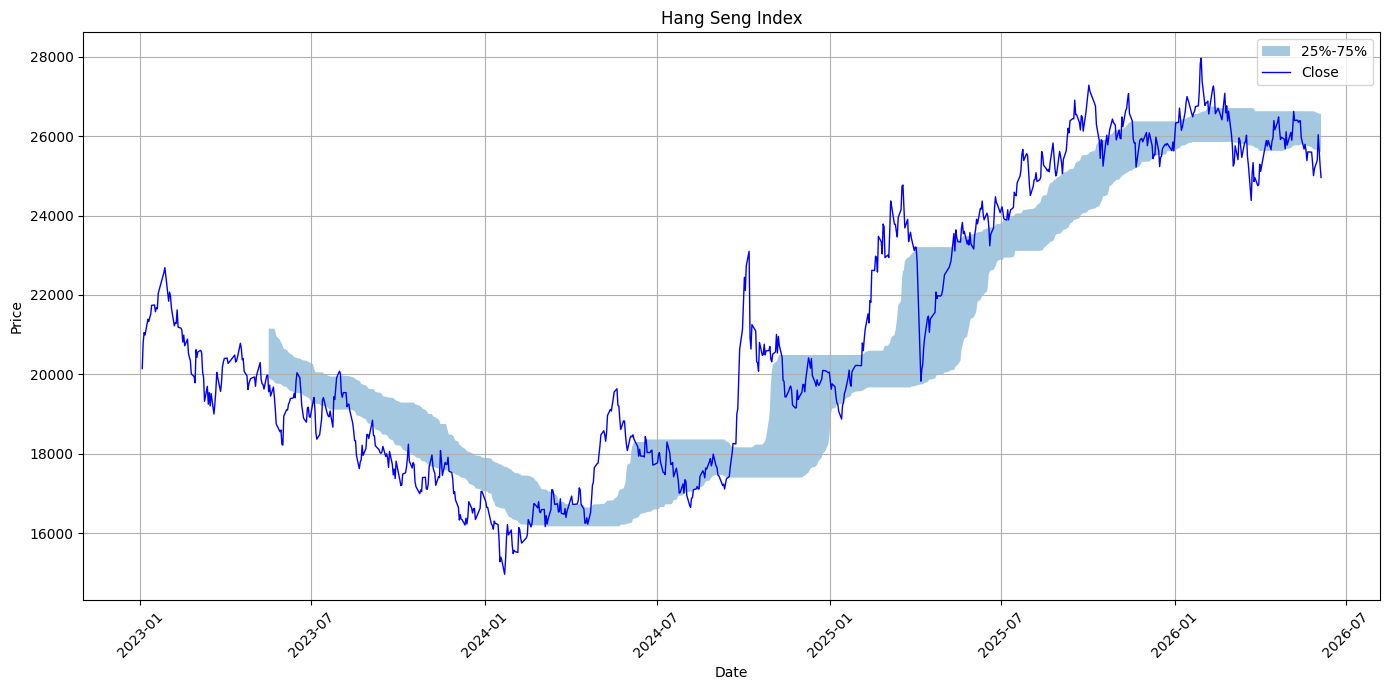

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv("data/hsi.csv")
data["date"] = pd.to_datetime(data["date"])
data = data[data['date'] >= pd.to_datetime("2023-01-01")]

# 计算滚动分位数
window = 90
data['p25'] = data['close'].rolling(window).quantile(0.25)
data['p75'] = data['close'].rolling(window).quantile(0.75)

plt.figure(figsize=(14, 7))
plt.fill_between(data['date'], data['p25'], data['p75'], alpha=0.4, label='25%-75%')
plt.plot(data['date'], data['close'], label='Close', color='blue', linewidth=1)
plt.title("Hang Seng Index")
plt.xlabel("Date")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.grid()
plt.legend()
plt.tight_layout()
plt.savefig("output/hsi_plot.png", dpi=300)
plt.show()

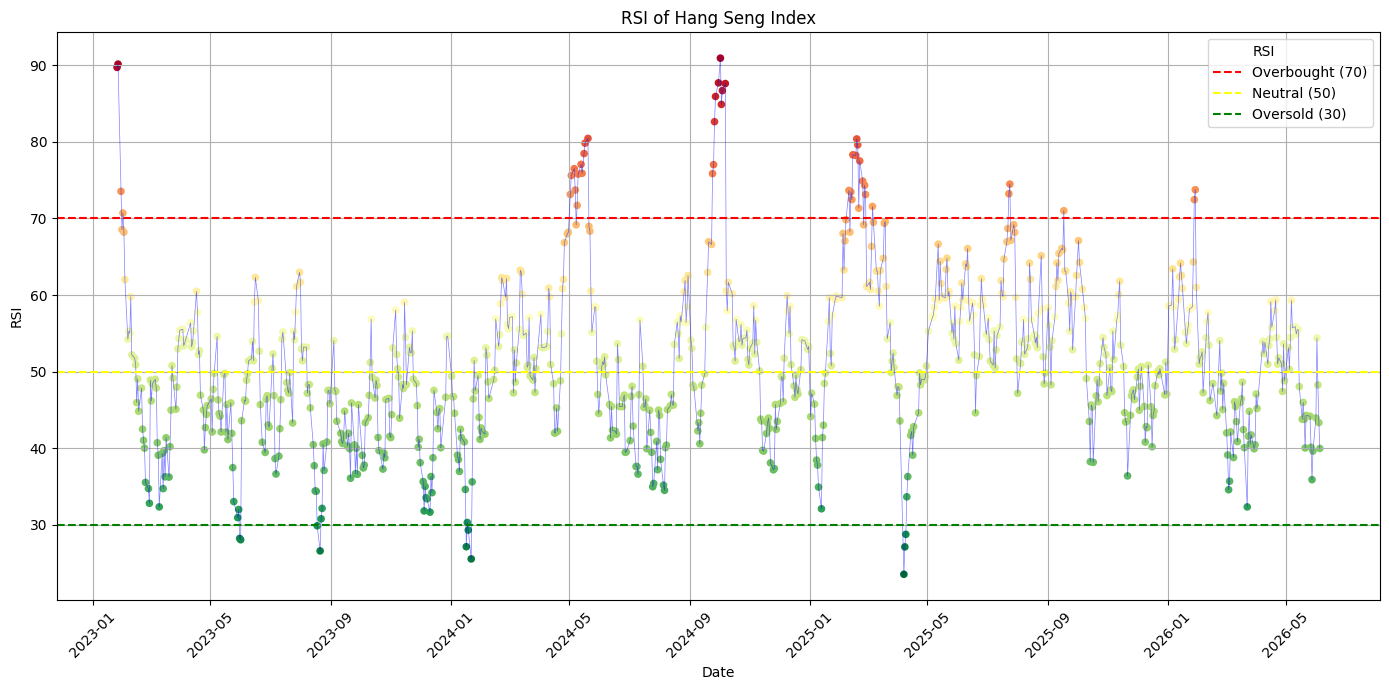

In [3]:
from src.calculate_rsi import calculate_rsi

data["rsi"] = calculate_rsi(data["close"].tolist(), window=14)

plt.figure(figsize=(14, 7))
scatter = plt.scatter(data["date"], data["rsi"], c=data["rsi"], cmap='RdYlGn_r', s=20, label="RSI")
plt.plot(data["date"], data["rsi"], color='blue', alpha=0.5, linewidth=0.5)
plt.axhline(70, color='red', linestyle='--', label='Overbought (70)')
plt.axhline(50, color='yellow', linestyle='--', label='Neutral (50)')
plt.axhline(30, color='green', linestyle='--', label='Oversold (30)')
plt.title("RSI of Hang Seng Index")
plt.xlabel("Date")
plt.ylabel("RSI")
plt.xticks(rotation=45)
plt.grid()
plt.legend()
plt.tight_layout()
plt.savefig("output/hsi_rsi_plot.png", dpi=300)
plt.show()